# Patient Comparison — Linear Regression Benchmark

This notebook runs Linear Regression analysis on **11 synthetic patient-comparison datasets** with different underlying scoring rules — some linear, some nonlinear.

**Schema** (same as the reference dataset):

| Columns | Meaning |
|---|---|
| `x1a, x2a, x3a, x4a` | Patient A's four features |
| `x1b, x2b, x3b, x4b` | Patient B's four features |
| `y` | `0` if A wins, `1` if B wins |

Every dataset has 800 rows, perfectly class-balanced (400 / 400). Feature marginal distributions match the original reference data.

**Goal.** See how a linear model fares against rules of increasing nonlinearity. The accuracy gap from the easy linear datasets (~95%+) down to the hardest nonlinear ones (XOR, ~60%) is the signal that the underlying preference structure is *not* representable as a weighted sum.


## Shared setup

We define an `analyze_dataset(filename)` helper that does what the original notebook did, in one call:

1. Loads the CSV.
2. Splits 80/20 train/test.
3. Fits a `LinearRegression`, thresholds predictions at 0.5 for class labels.
4. Prints MSE, R², accuracy, error %.
5. Plots the 8 coefficients and the paired (A + B) coefficient sums.

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# We collect results across all datasets so we can compare at the end.
RESULTS = {}

def analyze_dataset(filename, show_plots=True):
    """Run the Linear Regression pipeline on one dataset and print/plot results."""
    # Load data — relative path, so the .ipynb must sit next to the .csv files.
    data = np.loadtxt(filename, delimiter=",", skiprows=1)

    X = data[:, :8]
    y = data[:, 8]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_class = (y_pred >= 0.5).astype(int)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    accuracy = np.mean(y_pred_class == y_test) * 100
    error_percent = np.mean(y_pred_class != y_test) * 100

    print(f"=== {filename} ===")
    print("Coefficients:", np.round(model.coef_, 3))
    print("Intercept:   ", round(model.intercept_, 3))
    print(f"MSE:          {mse:.4f}")
    print(f"R\u00b2 Score:     {r2:.4f}")
    print(f"Accuracy:     {accuracy:.2f}%")
    print(f"Error %:      {error_percent:.2f}%")

    # Save for the final comparison.
    RESULTS[filename] = {
        "accuracy": accuracy,
        "mse": mse,
        "r2": r2,
        "coef": model.coef_.copy(),
        "intercept": model.intercept_,
    }

    if not show_plots:
        return

    feature_names_8 = ["A1", "A2", "A3", "A4", "B1", "B2", "B3", "B4"]
    feature_names_4 = ["A1+B1", "A2+B2", "A3+B3", "A4+B4"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    colors_8 = ["#4C9BE8"] * 4 + ["#E87A4C"] * 4
    axes[0].bar(feature_names_8, model.coef_, color=colors_8)
    axes[0].axhline(0, color="#888", linewidth=0.8)
    axes[0].set_xlabel("Features")
    axes[0].set_ylabel("Coefficient Value")
    axes[0].set_title(f"Feature coefficients  \u2014  {filename}")

    # Paired sum: under a perfect symmetric comparison model w_iA + w_iB = 0.
    # Non-zero values here signal that the linear fit is leaning on raw
    # absolute features rather than pure pairwise differences.
    coef_sum = model.coef_[0:4] + model.coef_[4:8]
    axes[1].bar(feature_names_4, coef_sum, color="#7A6FE8")
    axes[1].axhline(0, color="#888", linewidth=0.8)
    axes[1].set_xlabel("Feature pair")
    axes[1].set_ylabel("w(A) + w(B)")
    axes[1].set_title("Paired coefficient sum  (0 = perfectly symmetric)")

    plt.tight_layout()
    plt.show()


## 1. Linear — Weighted

**File:** `linear_weighted.csv`  
**Type:** Linear  
**Scoring rule:** $f(x) = 1.5 x_1 + 2.0 x_2 + 1.0 x_3 + 0.5 x_4$  
**Noise σ:** 0.5  

Different importance per feature, **no interaction terms**. Linear Regression should recover the coefficients almost exactly and reach very high accuracy (~95%+).

=== linear_weighted.csv ===
Coefficients: [-0.146 -0.178 -0.083 -0.042  0.149  0.171  0.089  0.029]
Intercept:    0.49
MSE:          0.0923
R² Score:     0.6307
Accuracy:     95.00%
Error %:      5.00%


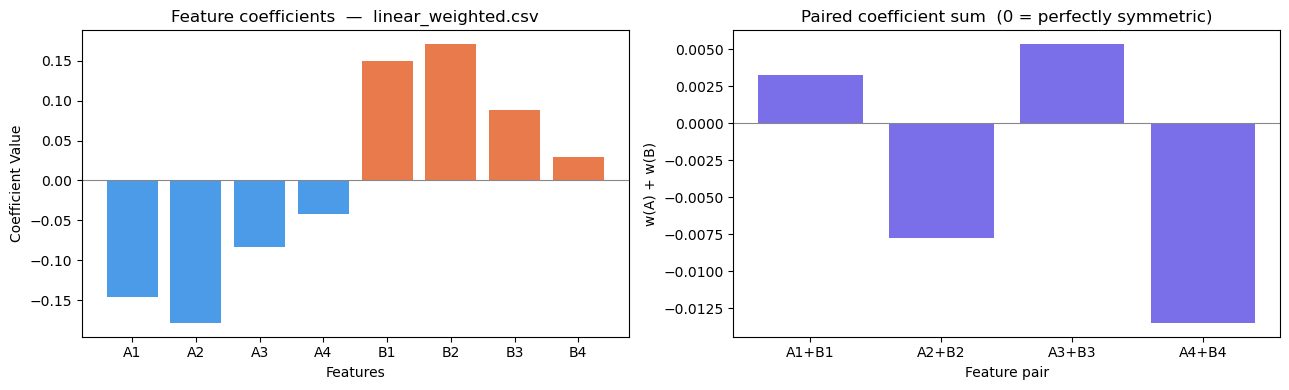

In [2]:
analyze_dataset("linear_weighted.csv")

## 2. Linear — Equal Weights

**File:** `linear_equal_weights.csv`  
**Type:** Linear  
**Scoring rule:** $f(x) = x_1 + x_2 + x_3 + x_4$  
**Noise σ:** 0.4  

Simplest linear sum — every feature contributes equally. Coefficients for A should be roughly equal and positive, coefficients for B roughly equal and negative.

=== linear_equal_weights.csv ===
Coefficients: [-0.127 -0.127 -0.122 -0.122  0.126  0.139  0.118  0.117]
Intercept:    0.496
MSE:          0.0872
R² Score:     0.6493
Accuracy:     94.38%
Error %:      5.62%


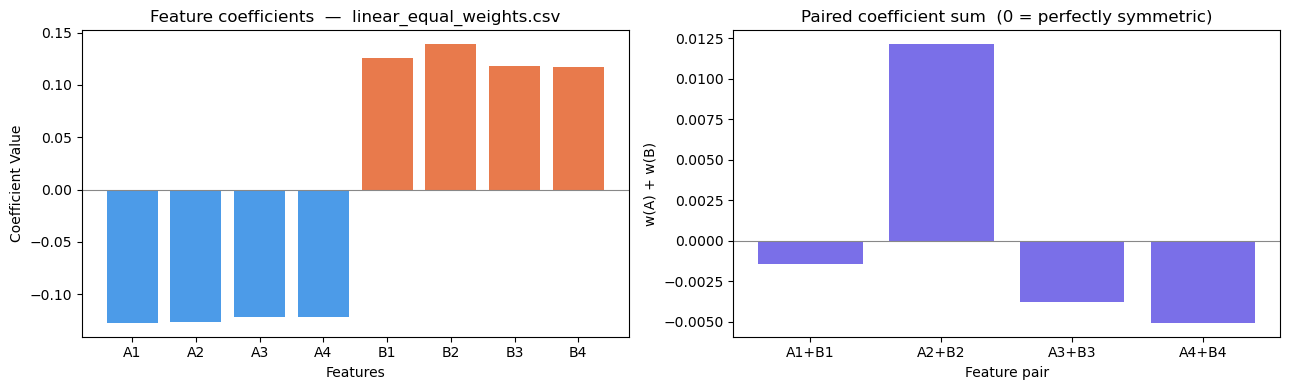

In [3]:
analyze_dataset("linear_equal_weights.csv")

## 3. Linear — High Noise

**File:** `linear_noisy.csv`  
**Type:** Linear (high noise)  
**Scoring rule:** $f(x) = 1.0 x_1 + 1.5 x_2 + 0.8 x_3 + 1.2 x_4$  
**Noise σ:** 2.5  

Same shape as a weighted linear model but with large Gaussian noise on each score. Even a perfect model is capped around ~75% accuracy here — the noise is part of the data-generating process. Useful for testing robustness.

=== linear_noisy.csv ===
Coefficients: [-0.074 -0.116 -0.069 -0.113  0.076  0.129  0.059  0.095]
Intercept:    0.524
MSE:          0.1408
R² Score:     0.4279
Accuracy:     80.62%
Error %:      19.38%


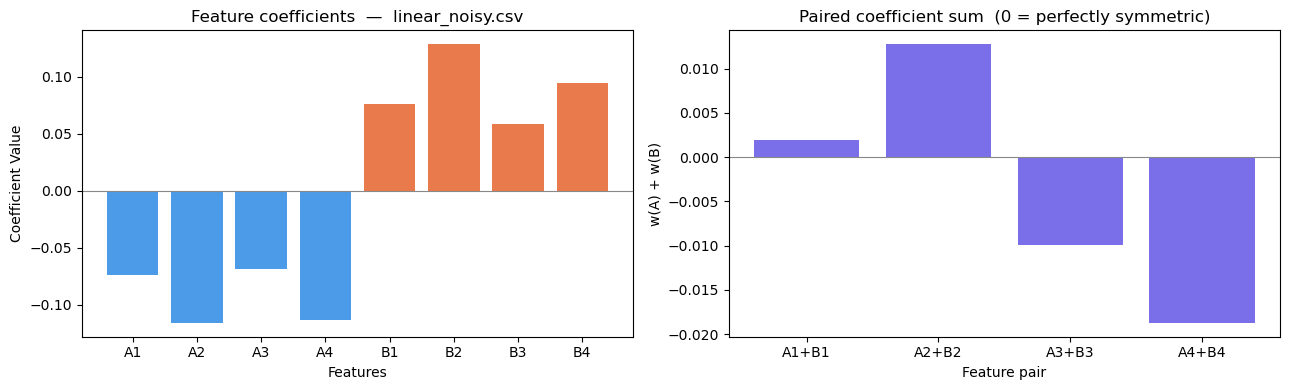

In [4]:
analyze_dataset("linear_noisy.csv")

## 4. Nonlinear — Polynomial Interaction

**File:** `polynomial_interaction.csv`  
**Type:** Nonlinear  
**Scoring rule:** $f(x) = x_1^2 + 0.5\, x_2 x_3 + x_4 - 0.3\, x_3^2$  
**Noise σ:** 0.8  

Squared terms and a cross term. A linear model can pick up the rough monotone trend but will miss the curvature. Expect a noticeable accuracy ceiling vs. a nonlinear model.

=== polynomial_interaction.csv ===
Coefficients: [-0.191 -0.04   0.025 -0.036  0.189  0.058 -0.018  0.065]
Intercept:    0.457
MSE:          0.1025
R² Score:     0.5859
Accuracy:     88.12%
Error %:      11.88%


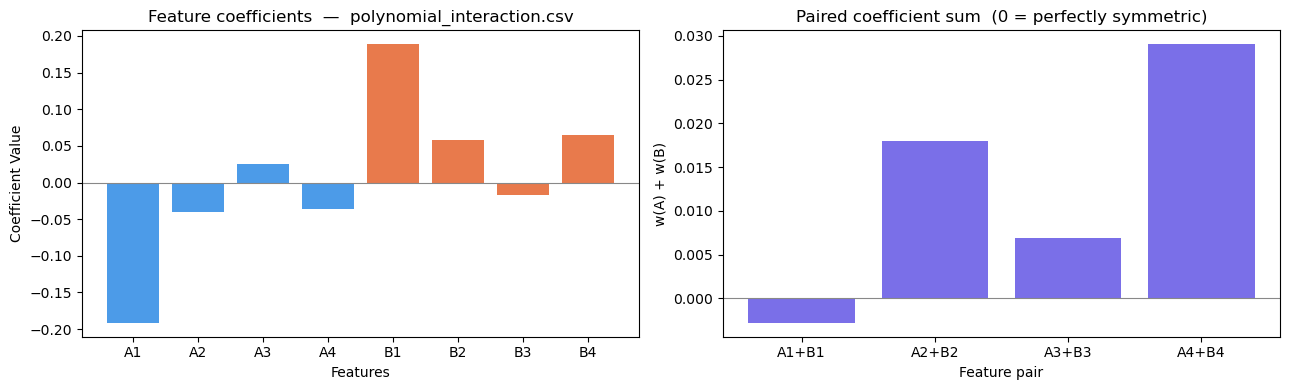

In [5]:
analyze_dataset("polynomial_interaction.csv")

## 5. Nonlinear — Threshold-Based

**File:** `threshold_based.csv`  
**Type:** Nonlinear (rule-based)  
**Scoring rule:** Step rules: `+4` if x₁≥3, `+2` if x₂≥2, `−3` if x₃≤0, `+1.5` if (x₄==1 ∧ x₁≥2)  
**Noise σ:** 0.6  

Decision-tree-style step functions. Linear Regression cannot represent step changes — it has to smear them out and will lose 5–10pp of accuracy compared to a tree model.

=== threshold_based.csv ===
Coefficients: [-0.113 -0.109 -0.073 -0.004  0.136  0.09   0.091  0.028]
Intercept:    0.419
MSE:          0.1597
R² Score:     0.3603
Accuracy:     77.50%
Error %:      22.50%


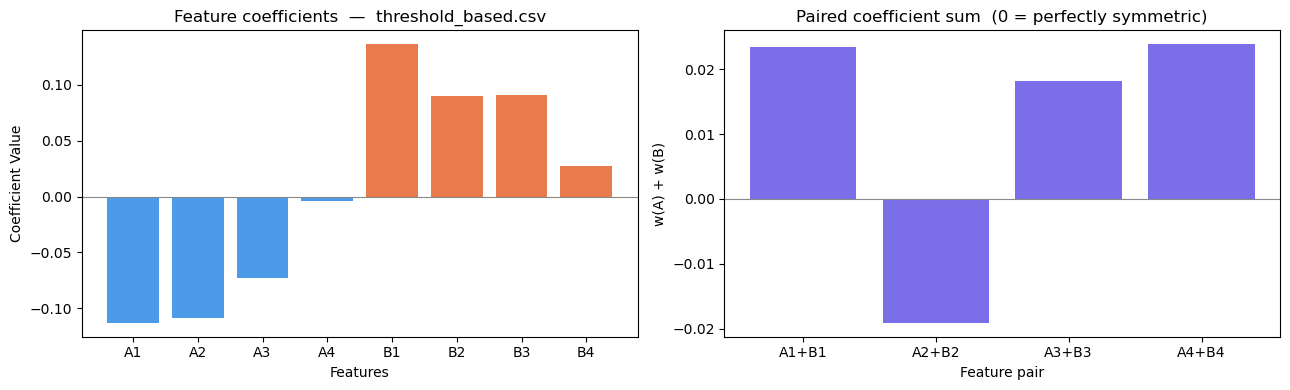

In [6]:
analyze_dataset("threshold_based.csv")

## 6. Nonlinear — Multiplicative Interactions

**File:** `multiplicative_relation.csv`  
**Type:** Nonlinear  
**Scoring rule:** $f(x) = x_1 x_2 + x_3 x_4$  
**Noise σ:** 0.7  

**Pure interactions, no main effects.** This is a classic stress test: a linear model with no interaction features is fundamentally mis-specified. The marginal correlation of each feature with y is weak.

=== multiplicative_relation.csv ===
Coefficients: [-0.07  -0.146 -0.071 -0.153  0.08   0.18   0.068  0.13 ]
Intercept:    0.488
MSE:          0.1547
R² Score:     0.3795
Accuracy:     80.62%
Error %:      19.38%


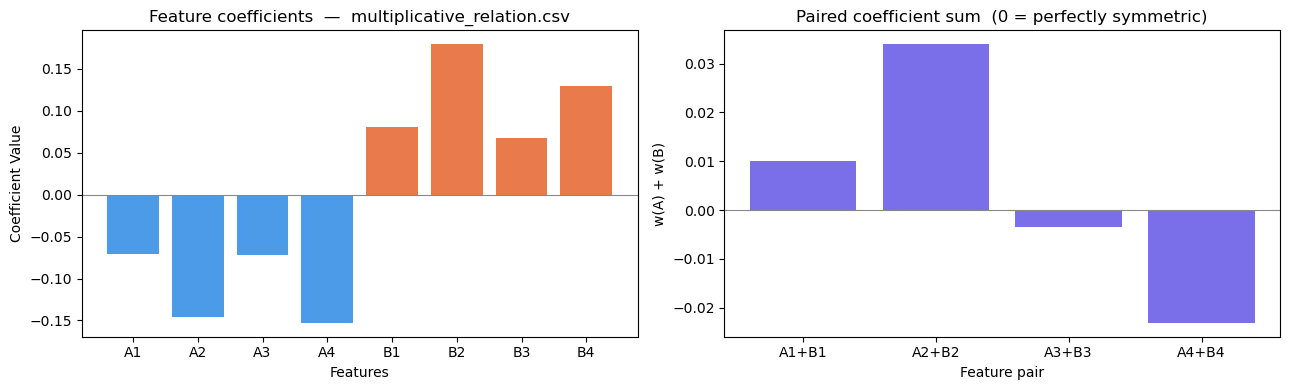

In [7]:
analyze_dataset("multiplicative_relation.csv")

## 7. Nonlinear — Exponential

**File:** `exponential_relation.csv`  
**Type:** Nonlinear  
**Scoring rule:** $f(x) = \exp(0.6 x_1) + \exp(0.4 x_2) + 0.3 x_3$  
**Noise σ:** 1.5  

Monotonic but heavily curved. A linear model can capture the monotonicity (so accuracy stays decent), but the marginal value of an extra unit at high x is much larger than at low x — which the linear model cannot express.

=== exponential_relation.csv ===
Coefficients: [-0.158 -0.039 -0.038  0.002  0.168  0.033  0.023  0.005]
Intercept:    0.498
MSE:          0.1519
R² Score:     0.3925
Accuracy:     76.25%
Error %:      23.75%


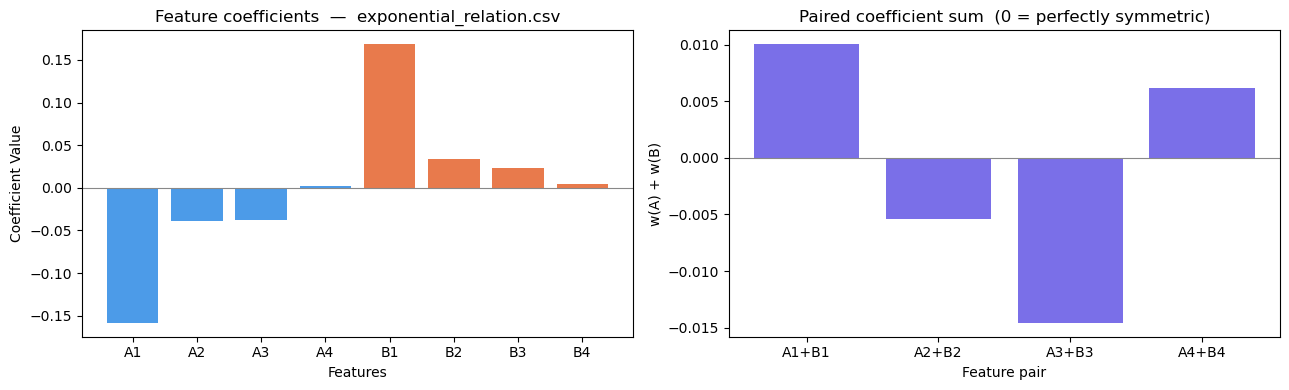

In [8]:
analyze_dataset("exponential_relation.csv")

## 8. Nonlinear — Logarithmic (Diminishing Returns)

**File:** `logarithmic_relation.csv`  
**Type:** Nonlinear  
**Scoring rule:** $f(x) = 2\log(1+x_1) + \log(2+x_3) + \sqrt{x_2+1} - 0.2 x_4$  
**Noise σ:** 0.3  

Concave / diminishing-returns rule — common in utility models. Because it's monotonic with smallish curvature over the integer feature range, a linear model gets fairly close.

=== logarithmic_relation.csv ===
Coefficients: [-0.178 -0.078 -0.068  0.057  0.16   0.079  0.066 -0.034]
Intercept:    0.518
MSE:          0.0894
R² Score:     0.6402
Accuracy:     93.75%
Error %:      6.25%


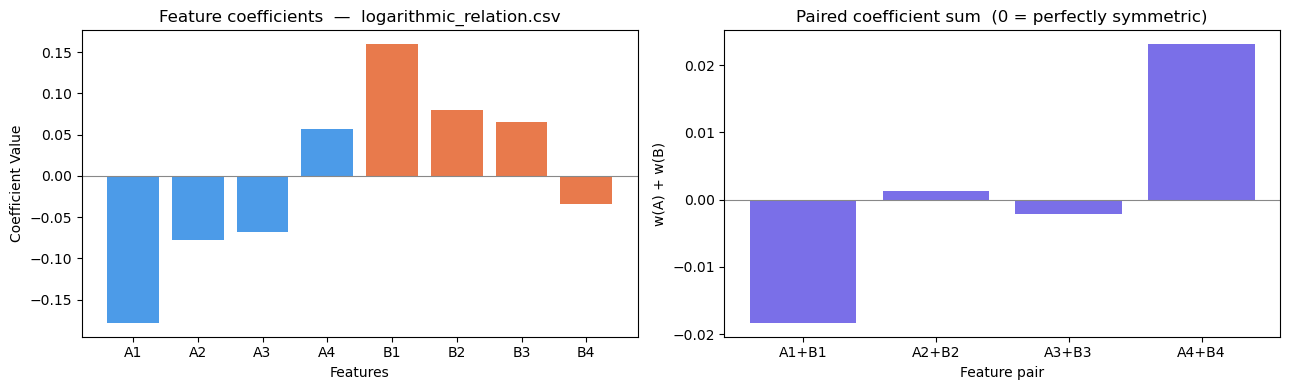

In [9]:
analyze_dataset("logarithmic_relation.csv")

## 9. Nonlinear — Piecewise Decision System

**File:** `piecewise_decision.csv`  
**Type:** Nonlinear (rule-based)  
**Scoring rule:** 5-branch if/elif rule (clinical-decision-tree style)  
**Noise σ:** 0.7  

Multiple mutually-exclusive branches, each with its own scoring formula. A linear model has to average over all branches — it cannot route by branch. Expect a clear gap versus a tree-based model.

=== piecewise_decision.csv ===
Coefficients: [-0.066 -0.152 -0.042 -0.109  0.097  0.202  0.053  0.115]
Intercept:    0.379
MSE:          0.1569
R² Score:     0.3714
Accuracy:     76.88%
Error %:      23.12%


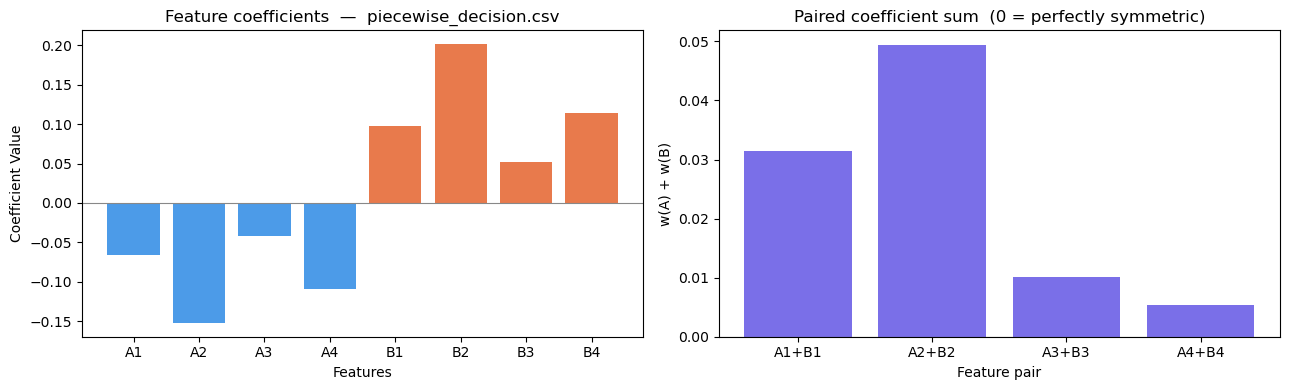

In [10]:
analyze_dataset("piecewise_decision.csv")

## 10. Nonlinear — Hidden Units (NN-style)

**File:** `hidden_nonlinear.csv`  
**Type:** Nonlinear (neural-net-like)  
**Scoring rule:** $f(x) = 2 \tanh(w_1 \cdot x) - 1.5 \tanh(w_2 \cdot x) + 0.5 \tanh(w_1 \cdot x) \tanh(w_2 \cdot x)$  
**Noise σ:** 0.25  

Two `tanh` hidden units combined with a product term — what a tiny MLP would compute. Smooth but genuinely nonlinear. Linear models do surprisingly OK because `tanh` is roughly linear for small inputs, but a flexible model still wins.

=== hidden_nonlinear.csv ===
Coefficients: [-0.131  0.167 -0.064  0.164  0.139 -0.195  0.066 -0.177]
Intercept:    0.513
MSE:          0.0997
R² Score:     0.6012
Accuracy:     89.38%
Error %:      10.62%


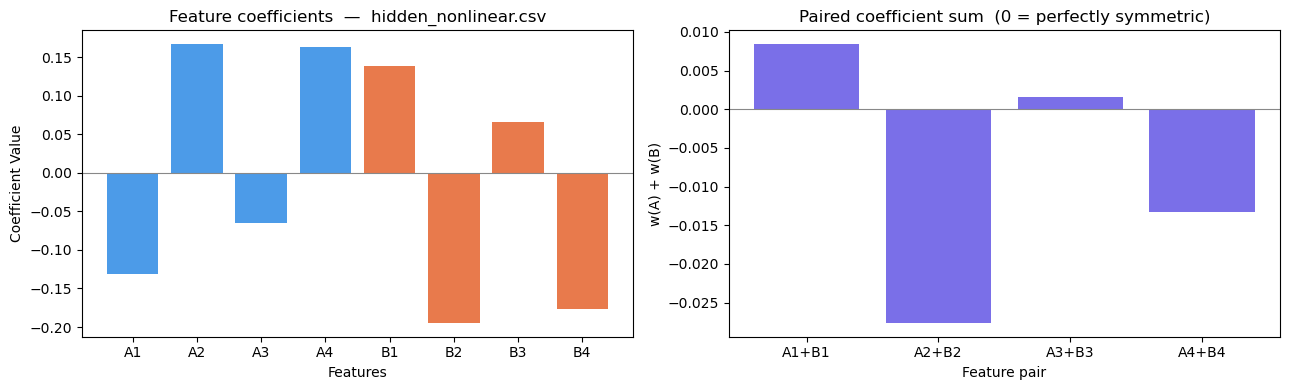

In [11]:
analyze_dataset("hidden_nonlinear.csv")

## 11. Nonlinear — XOR Pattern

**File:** `xor_like.csv`  
**Type:** Nonlinear (XOR)  
**Scoring rule:** Score = +5 if exactly one of (x₁≥2, x₂≥1) holds, −1 if both or neither, plus small main effects  
**Noise σ:** 0.8  

**The textbook unlearnable-by-linear case.** Linear Regression will collapse to near-chance (~60%) accuracy. Any model that can represent feature interactions (trees, kernels, MLPs) should easily reach 75–80%.

=== xor_like.csv ===
Coefficients: [ 0.041  0.056 -0.05   0.012 -0.027 -0.03   0.008 -0.053]
Intercept:    0.556
MSE:          0.2499
R² Score:     0.0004
Accuracy:     55.62%
Error %:      44.38%


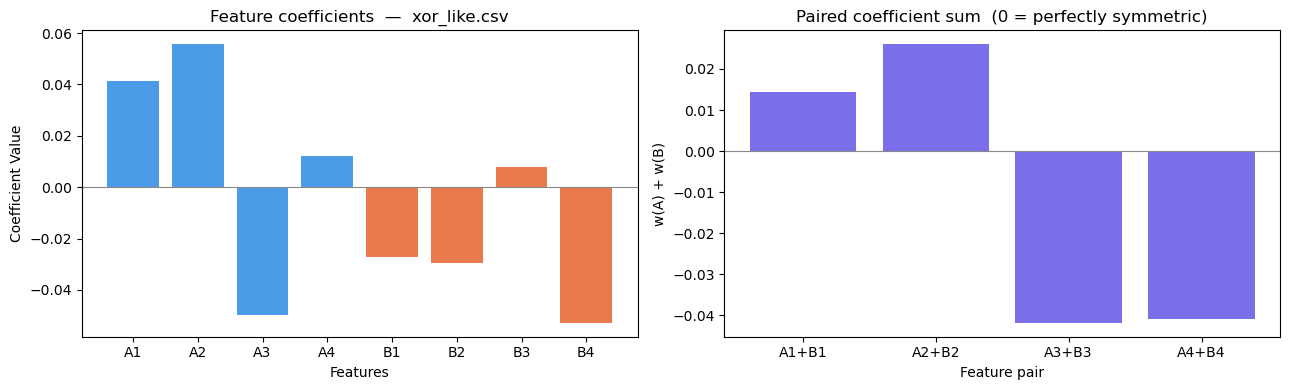

In [12]:
analyze_dataset("xor_like.csv")

## Cross-dataset comparison

Now we line up the linear-model accuracy across all 11 datasets in one chart. The pattern is the headline of this benchmark: the linear datasets are at the top, the smooth nonlinear ones in the middle, and the discontinuous / interaction-heavy ones at the bottom.

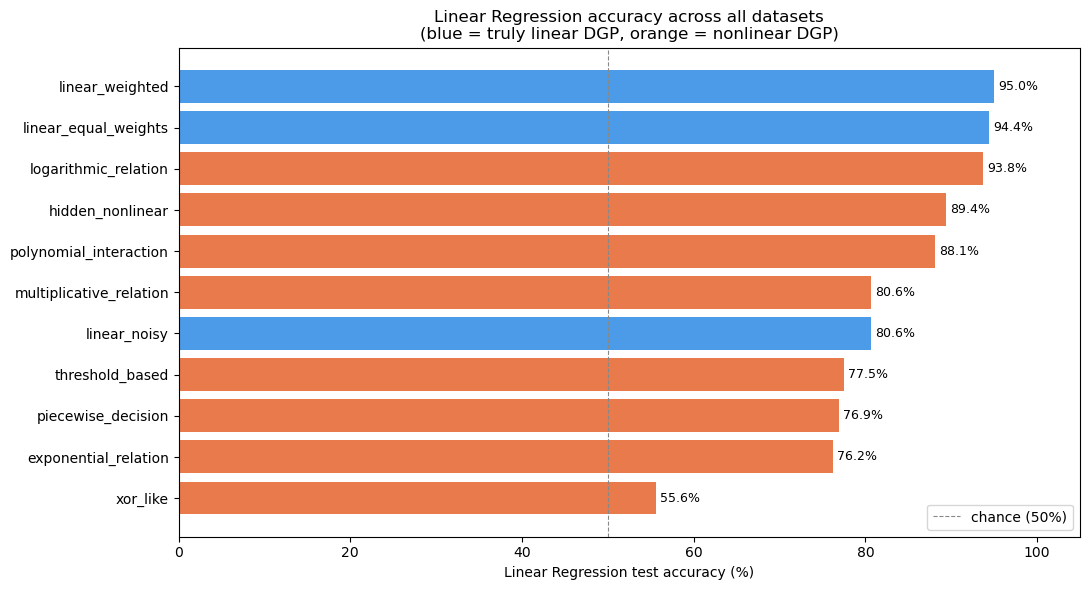

In [13]:
# Sort datasets by Linear Regression accuracy, ascending.
rows = sorted(RESULTS.items(), key=lambda kv: kv[1]["accuracy"])
names = [k.replace(".csv", "") for k, _ in rows]
accs  = [v["accuracy"] for _, v in rows]

# Colour by linear vs nonlinear so the structure jumps out.
LINEAR_FILES = {"linear_weighted.csv",
                "linear_equal_weights.csv",
                "linear_noisy.csv"}
colors = ["#4C9BE8" if (k in LINEAR_FILES) else "#E87A4C"
          for k, _ in rows]

plt.figure(figsize=(11, 6))
bars = plt.barh(names, accs, color=colors)
plt.axvline(50, color="#888", linestyle="--", linewidth=0.8,
            label="chance (50%)")
plt.xlabel("Linear Regression test accuracy (%)")
plt.title("Linear Regression accuracy across all datasets\n"
          "(blue = truly linear DGP, orange = nonlinear DGP)")
for bar, a in zip(bars, accs):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{a:.1f}%", va="center", fontsize=9)
plt.xlim(0, 105)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Reading the chart

- **Top of the chart (high accuracy):** datasets whose rule is well-approximated by a weighted sum. The three blue bars (`linear_*`) live here, as do monotonic nonlinear rules like `logarithmic_relation` and `hidden_nonlinear`.
- **Middle:** smooth nonlinear rules where a linear model captures the trend but misses curvature (`exponential_relation`, `polynomial_interaction`).
- **Bottom:** rules that fundamentally cannot be expressed as a weighted sum — `xor_like` is the textbook case (XOR is unlearnable by any linear model). `threshold_based`, `multiplicative_relation`, and `piecewise_decision` join it because they all hinge on feature interactions or step functions that linear coefficients cannot encode.

### Sanity check on the coefficients

Look back at the paired-coefficient-sum plots: for the truly linear datasets, `w(A) + w(B)` should be close to zero (the rule is symmetric and antisymmetric across A and B). For the nonlinear ones, that symmetry can leak — non-zero sums indicate the linear model is compensating for unmodelled structure by leaning on absolute feature values rather than pure A-vs-B differences.

### Next step

To prove the **bottom** of the chart really *is* nonlinear (and not just noisy), we can swap `LinearRegression` for a `GradientBoostingClassifier` or `RandomForestClassifier` and re-run. The linear datasets at the top should stay roughly the same; the bottom ones should jump 5–20 percentage points. That gap is the linear-vs-nonlinear signal.